# PDAN8411 — POE Part 1: Linear Regression
### Predicting Medical Insurance Charges

**Dataset:** insurance.csv  
**Target Variable:** `charges` (continuous — medical cost billed by insurance)  
**Problem Type:** Regression  

---

**Pipeline Overview:**
1. Load and Inspect the Data
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing (Encoding + Scaling)
4. Train / Test Split
5. Build Linear Regression Model
6. Evaluate the Model (MAE, MSE, RMSE, R²)
7. Residual Diagnostics (check the 4 assumptions)
8. Ridge, Lasso and Elastic Net Regression

## 1. Import Libraries

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [61]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Initial Data Inspection

Before doing anything to the data we first need to understand its structure — how many rows and columns it has, what the data types are, and whether there are any missing values.

In [62]:
# show the number of rows and columns in the dataset
df.shape

(1338, 7)

In [63]:
# show the column names, data types and whether there are null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### DataFrame Information

The `info()` function gives us a structural overview of the dataset. It shows the **number of entries**, the **column names**, the **data types** of each column, and whether there are any **null/missing values**.

From the output we can see:
- The dataset contains **1338 rows and 7 columns**
- There are **no missing values** — all columns show 1338 non-null entries
- There are **3 categorical (object) columns**: `sex`, `smoker`, and `region` — these will need to be encoded before being fed into the model
- There are **4 numerical columns**: `age`, `bmi`, `children`, and `charges`

In [64]:
# statistical summary for all columns — include='all' covers categorical columns too
# numeric: count, mean, std, min, quartiles, max
# categorical: count, unique, top (most frequent value), freq
df.describe(include='all')

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Descriptive Statistics

The `describe()` function gives us a quick statistical summary of all numerical columns.

Key observations:
- **Age** ranges from 18 to 64 with a mean of ~39
- **BMI** has a mean of ~30.7. The max of 53.1 suggests **potential outliers** on the upper end
- **Children** ranges from 0 to 5, with a median of 1
- **Charges** has a mean of ~$13,270 but a max of ~$63,770 — this large gap suggests the distribution is **right-skewed**

In [65]:
# check for any missing/null values across all columns
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Duplicate Row Check

Duplicate rows can cause the model to overfit — it effectively memorises the same record more than once. We check for duplicates at this stage, before any transformations, so the inspection is done on the raw data.

In [ ]:
# count exact duplicate rows — all columns must match
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found — dataset is clean.')

## 4. Exploratory Data Analysis (EDA)

EDA is done **before** any preprocessing. The goal is to understand the data in its raw, human-readable form — how the target is distributed, how features relate to the target, and whether any features are redundant.

We follow three levels:
- **Univariate** — each feature in isolation
- **Bivariate** — each feature vs the target
- **Multivariate** — how features relate to each other

### 4.1 Univariate Analysis — Target Variable Distribution

For regression we always check the **distribution of the target variable** first. If it is heavily skewed, the model's predictions will also be skewed. We use a histogram and a box plot together.

/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


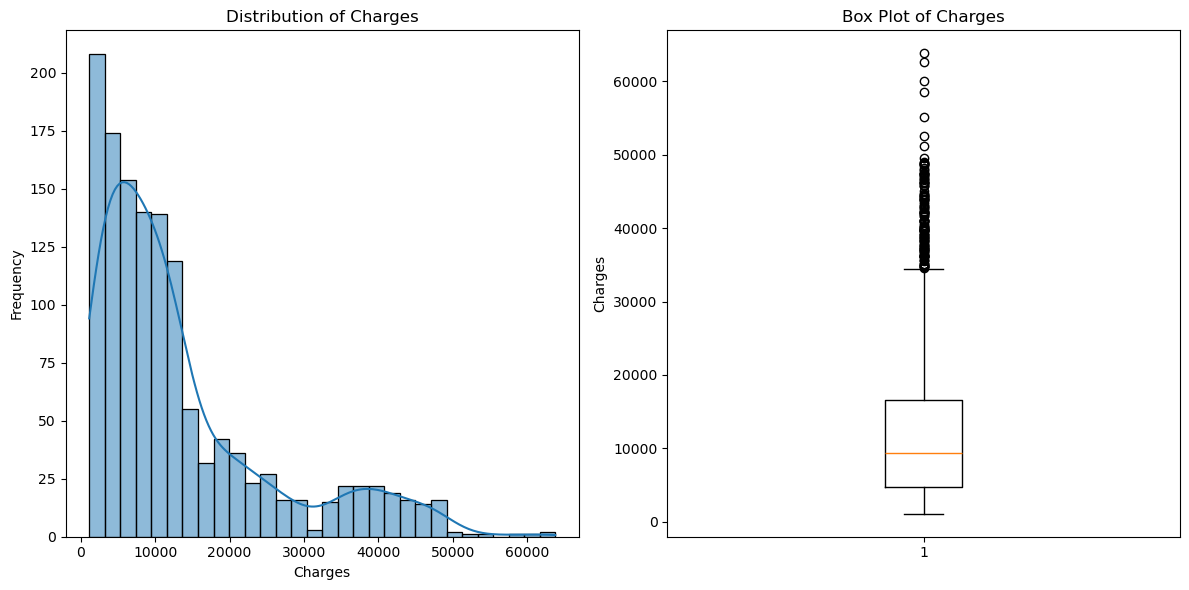

In [66]:
# plot the distribution of the target variable using a histogram and box plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(df['charges'], ax=axes[0], kde=True, bins=30)
axes[0].set_title('Distribution of Charges')
axes[0].set_xlabel('Charges')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['charges'])
axes[1].set_title('Box Plot of Charges')
axes[1].set_ylabel('Charges')

plt.tight_layout()
plt.show()

### Target Variable Analysis

From the histogram `charges` is **right-skewed** — most patients have low charges but a small group has very high charges creating a long tail to the right. The box plot confirms several **outliers** above the upper whisker.

To fix this we apply a **log transformation**. This compresses large values and spreads smaller ones, bringing the distribution closer to normal. Linear Regression assumes residuals are normally distributed — if the target is skewed this assumption is violated.

In [67]:
# apply a log transformation to fix the skewness in the target variable
df['charges_log'] = np.log(df['charges'])

/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


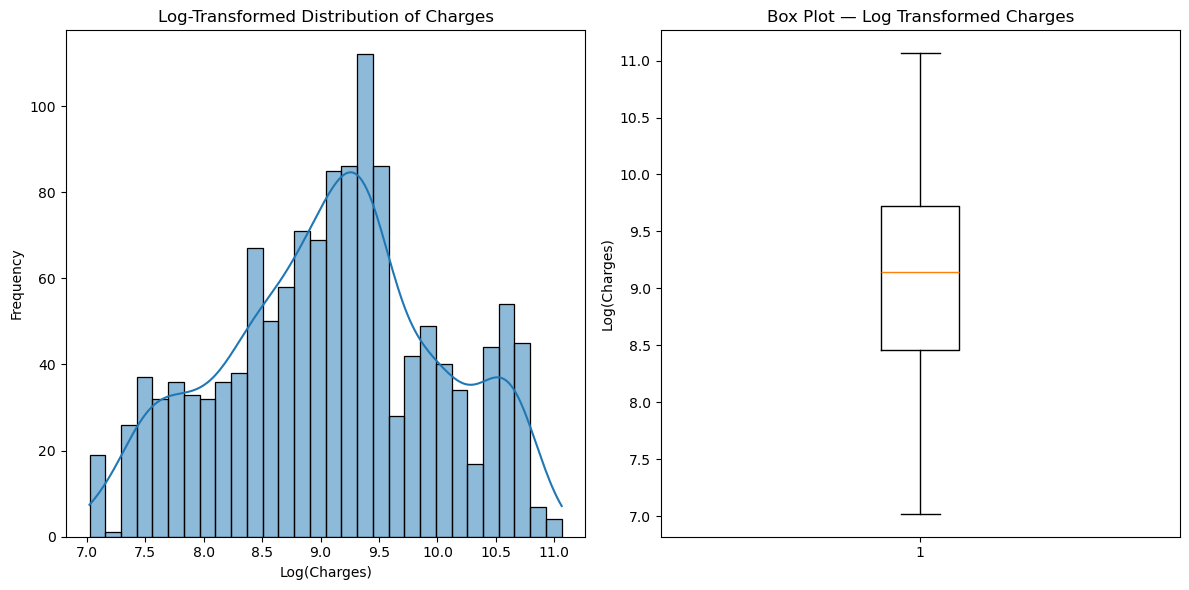

In [68]:
# compare the original and log-transformed target side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(df['charges_log'], ax=axes[0], kde=True, bins=30)
axes[0].set_title('Log-Transformed Distribution of Charges')
axes[0].set_xlabel('Log(Charges)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['charges_log'])
axes[1].set_title('Box Plot — Log Transformed Charges')
axes[1].set_ylabel('Log(Charges)')

plt.tight_layout()
plt.show()

### Effect of the Log Transformation

After the log transformation the distribution is now **much more symmetric and closer to a normal distribution**. The histogram shows a bell-shaped curve and the box plot shows far fewer outliers.

This matters because **Linear Regression assumes that residuals are normally distributed** around zero. A skewed target produces skewed residuals which violates this assumption and reduces model reliability.

### 4.2 Univariate Analysis — Categorical Features

For categorical features we check **value counts** to understand how many records belong to each category and whether there are any imbalances.

In [69]:
# check the value counts for each categorical feature
for col in ['sex', 'smoker', 'region']:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

--- sex ---
sex
male      676
female    662
Name: count, dtype: int64

--- smoker ---
smoker
no     1064
yes     274
Name: count, dtype: int64

--- region ---
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



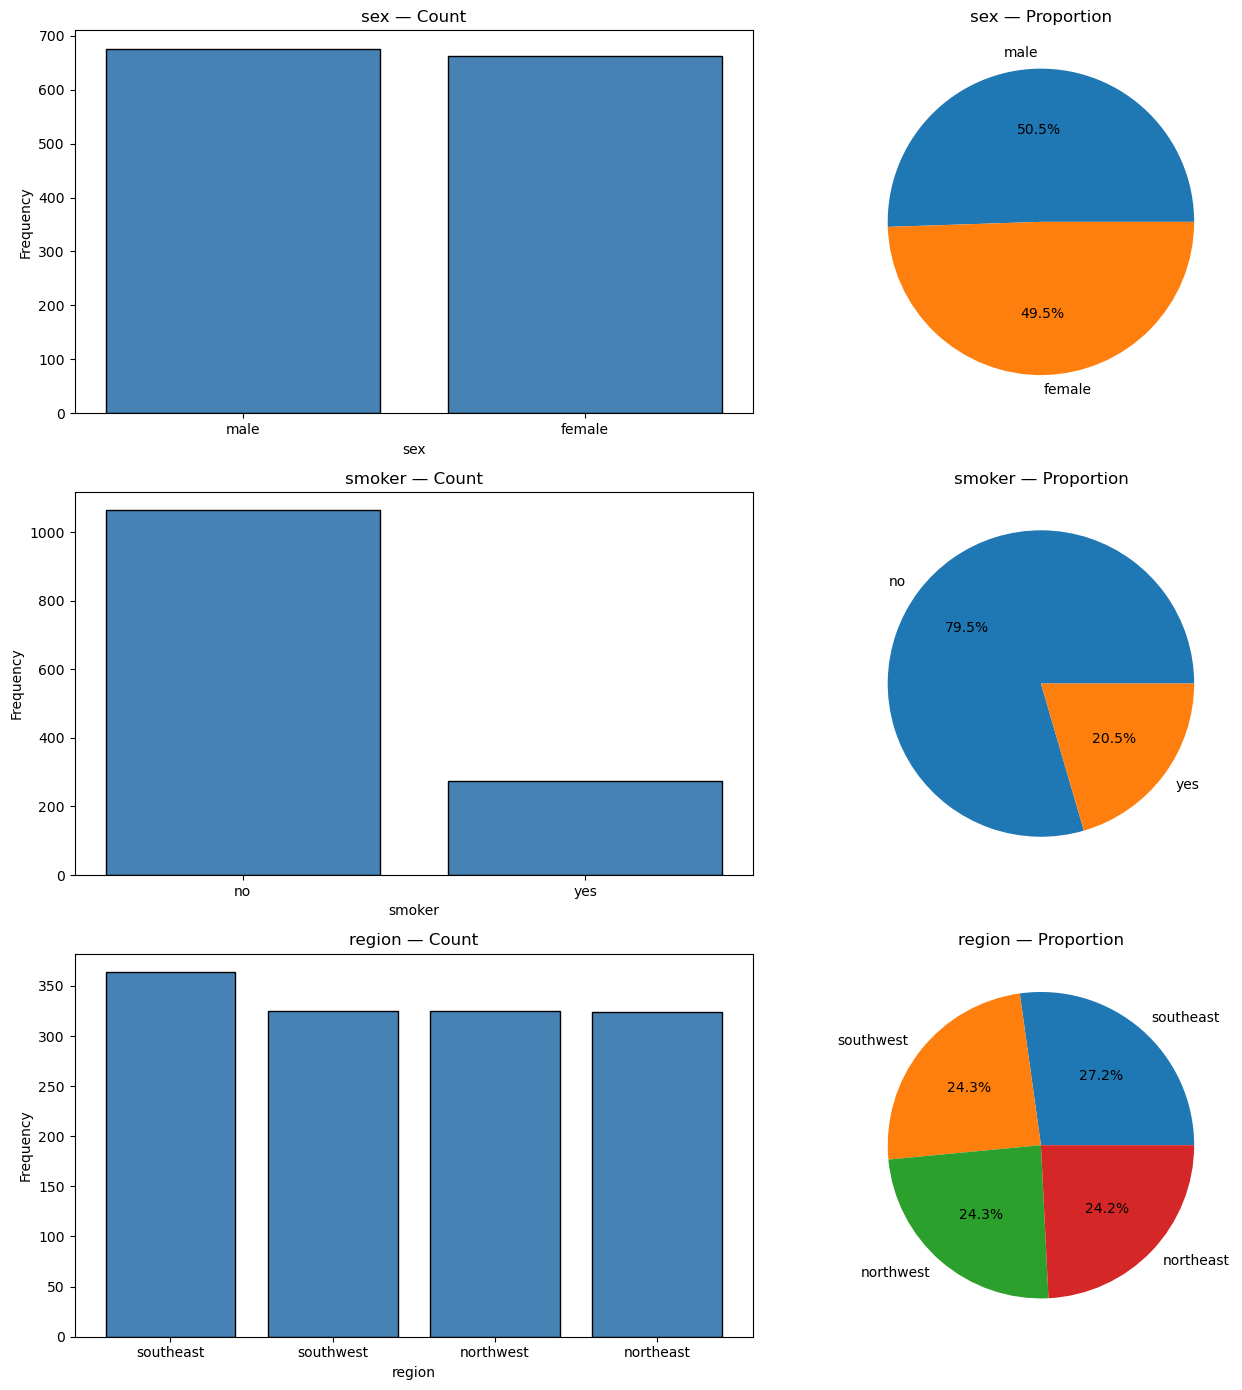

In [70]:
# visualise the distribution of categorical features using bar charts and pie charts
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for i, col in enumerate(['sex', 'smoker', 'region']):
    counts = df[col].value_counts()
    axes[i, 0].bar(counts.index, counts.values, color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'{col} — Count')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 1].pie(counts.values, labels=counts.index, autopct='%1.1f%%')
    axes[i, 1].set_title(f'{col} — Proportion')

plt.tight_layout()
plt.show()

### Categorical Feature Distribution

- **Sex**: Nearly evenly split (~50.5% male, ~49.5% female) — no class imbalance
- **Smoker**: ~79.5% non-smokers and ~20.5% smokers — this imbalance is important as smokers are likely to have significantly higher charges
- **Region**: Fairly even across four US regions, southeast has slightly more records

### 4.3 Bivariate Analysis — Features vs Target

Bivariate analysis checks whether each individual feature has a **relationship with the target variable**. For numerical features we use scatter plots. For categorical features we use box plots to see how charges differ across each category.

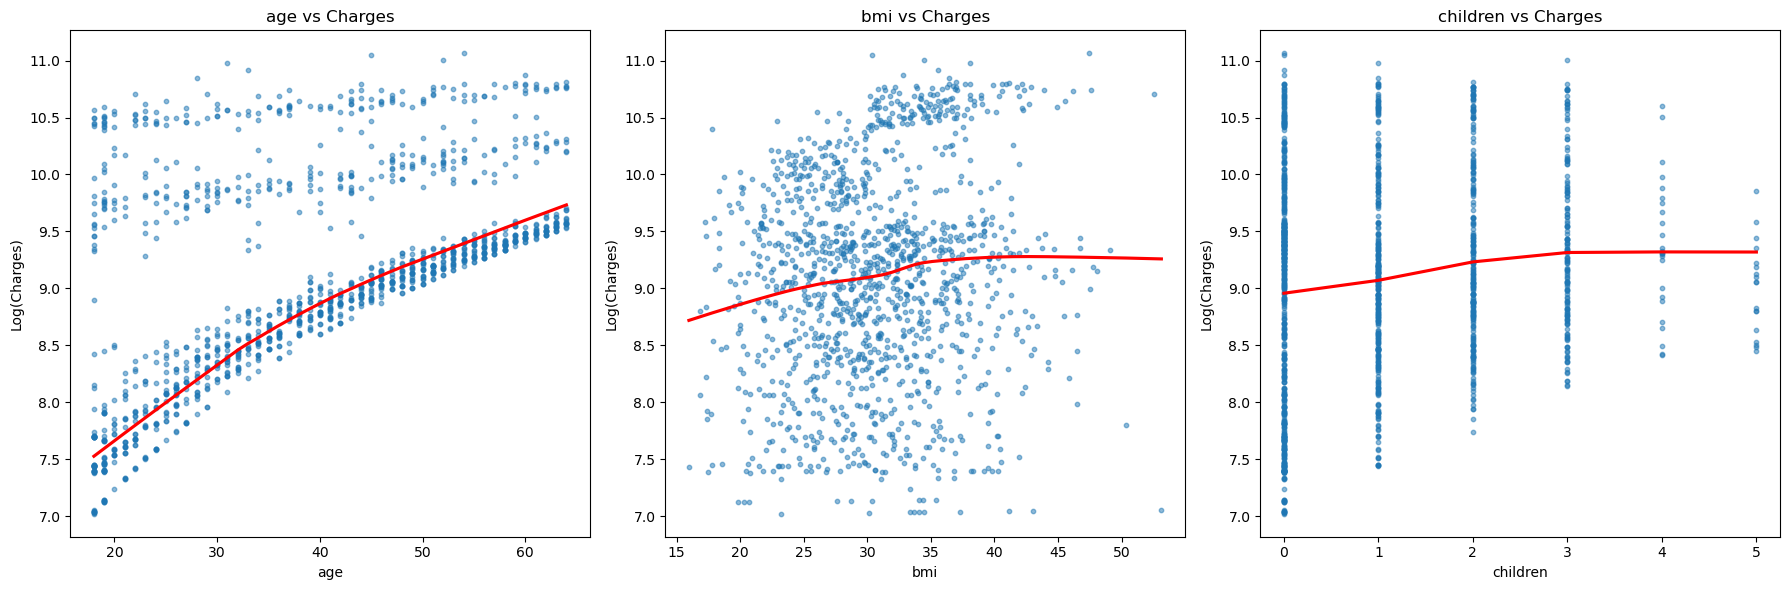

In [71]:
# scatter plots for numerical features vs the log-transformed target
# the red regression line shows the direction and strength of the relationship
num_features = ['age', 'bmi', 'children']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    axes[i].scatter(df[feature], df['charges_log'], alpha=0.5, s=10)
    sns.regplot(x=df[feature], y=df['charges_log'], ax=axes[i], scatter=False, lowess=True, color='red')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Log(Charges)')
    axes[i].set_title(f'{feature} vs Charges')

plt.tight_layout()
plt.show()

### Numerical Features vs Target

- **Age vs Charges**: Clear **positive linear relationship** — charges increase steadily with age. Strong predictor
- **BMI vs Charges**: Weak positive relationship with a lot of spread. BMI likely interacts with other variables like smoking status
- **Children vs Charges**: Very weak relationship — the regression line is nearly flat. Number of dependents has minimal impact on charges

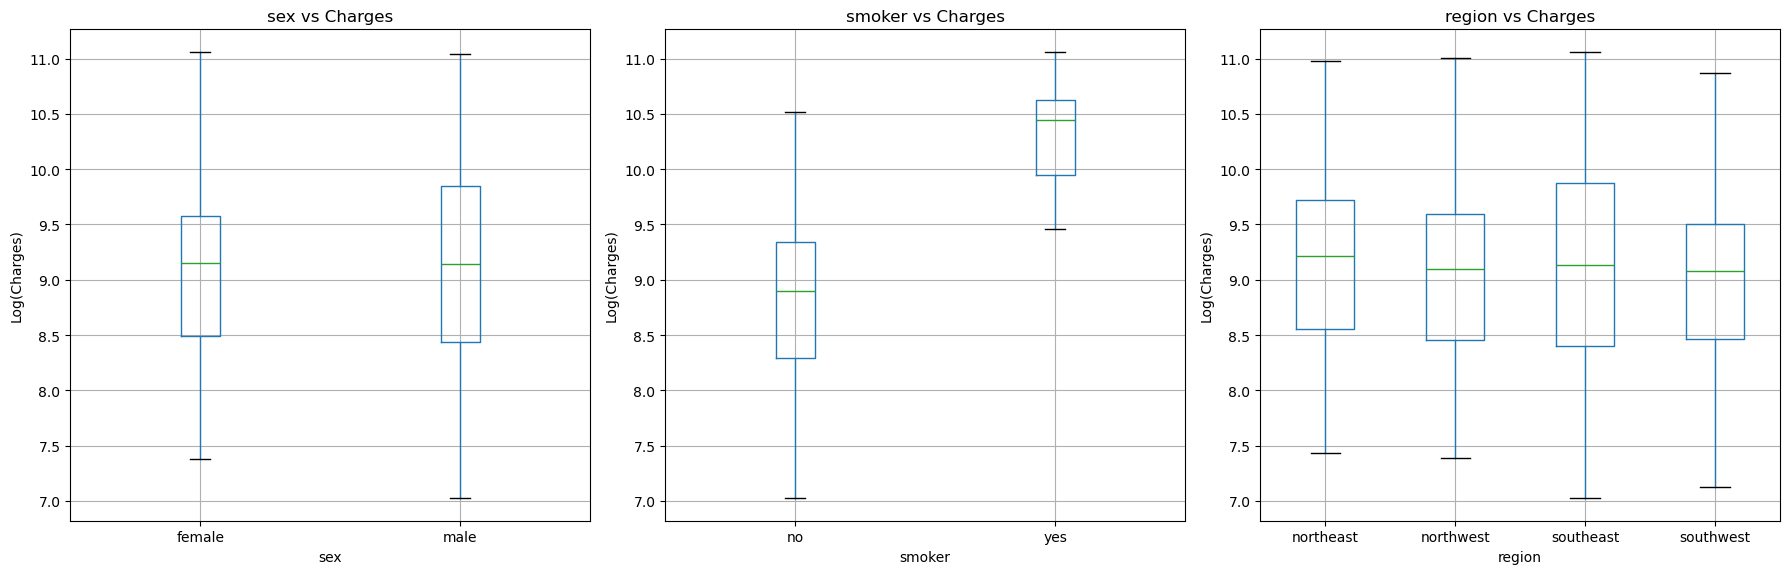

In [72]:
# box plots for categorical features to see how charges differ across each category
cat_features = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(cat_features):
    df.boxplot(column='charges_log', by=feature, ax=axes[i])
    axes[i].set_title(f'{feature} vs Charges')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Log(Charges)')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Categorical Features vs Target

- **Sex vs Charges**: Distributions are very similar — medians close, boxes heavily overlapping. Sex is a **weak predictor**
- **Smoker vs Charges**: Most important result in the EDA. Smokers have dramatically higher charges — the smoker box sits entirely above the non-smoker box with almost no overlap. `smoker` is the **strongest predictor** in this dataset
- **Region vs Charges**: All four regions show similar distributions. Region is a weak predictor

### 4.4 Multivariate Analysis — Correlation Heatmap

The correlation heatmap shows the **strength of linear relationships between all pairs of numerical features**. We use this to:
1. See which numerical features correlate most with `charges_log`
2. Detect **multicollinearity** — if two features correlate above 0.95 with each other, one should be dropped

Note: Categorical features do not appear here as they have not been encoded yet. Their impact was explored through the box plots above.

charges_log    1.000000
age            0.527834
children       0.161336
bmi            0.132669
Name: charges_log, dtype: float64


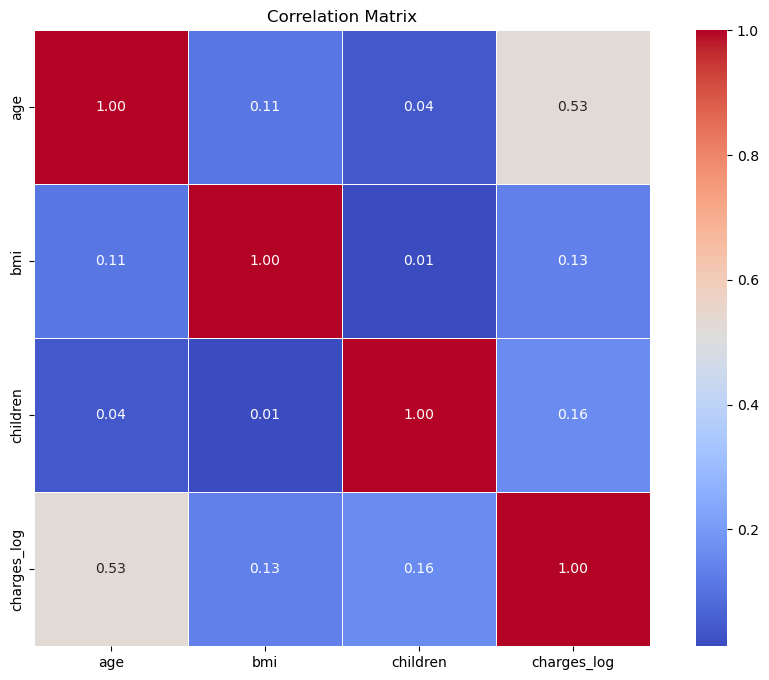

In [73]:
# select only the numerical columns for the correlation matrix
df_corr = df[['age', 'bmi', 'children', 'charges_log']]

# print correlation of each feature with the target, sorted highest to lowest
# this shows which numerical features have the strongest relationship with charges
correlations = df_corr.corr()['charges_log'].sort_values(ascending=False)
print(correlations)

# heatmap showing all pairwise correlations — checks for multicollinearity
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidth=0.5)
plt.title('Correlation Matrix')
plt.show()

### Correlation Matrix Analysis

- **Age** has the strongest positive correlation (~0.53) — moderate but strong for real-world data
- **BMI** (~0.13) and **children** (~0.16) are weak individually
- **No pair of features exceeds 0.95** — no multicollinearity, all features can be retained

Important: these low values do not mean the model will perform poorly. The strongest predictor (`smoker`) is categorical and not shown here. Once encoded it will contribute significantly to the model's R² score.

## 5. Data Preprocessing

The preprocessing pipeline follows this exact order:
1. **Encode** categorical features first — so both train and test sets get identical columns
2. **Split** into train and test sets
3. **Scale** numerical features after splitting — to prevent **data leakage** (fitting the scaler on the full dataset would let test data influence the model's training)

### 5.1 Encoding Categorical Features

We use **One-Hot Encoding** (`pd.get_dummies`). This converts each category into a binary column (0 or 1). `drop_first=True` removes one column per feature to avoid the **dummy variable trap** — where one column is perfectly predictable from the others, introducing multicollinearity.

In [74]:
# select the features we will use — include the log-transformed target
df_model = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges_log']].copy()
df_model.head()

,age,sex,bmi,children,smoker,region,charges_log
0,19,female,27.900,0,yes,southwest,9.734176
1,18,male,33.770,1,no,southeast,7.453302
2,28,male,33.000,3,no,southeast,8.400538
3,33,male,22.705,0,no,northwest,9.998092
4,32,male,28.880,0,no,northwest,8.260197


In [75]:
# encode the categorical columns using one-hot encoding
# drop_first=True removes one category per feature to avoid the dummy variable trap
df_model = pd.get_dummies(df_model, columns=['sex', 'smoker', 'region'], drop_first=True)
df_model.head()

,age,bmi,children,charges_log,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,9.734176,False,True,False,False,True
1,18,33.770,1,7.453302,True,False,False,True,False
2,28,33.000,3,8.400538,True,False,False,True,False
3,33,22.705,0,9.998092,True,False,True,False,False
4,32,28.880,0,8.260197,True,False,True,False,False


In [76]:
# confirm the new dummy columns were created correctly
df_model.columns

Index(['age', 'bmi', 'children', 'charges_log', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

### 5.1b Multicollinearity Check — Variance Inflation Factor (VIF)

Before we split the data it is good practice to check for **multicollinearity** — when two or more features are highly correlated with each other. This can inflate coefficient estimates and make the model less interpretable.

**VIF interpretation:**
- VIF = 1 — no correlation with other features
- VIF 1–5 — moderate, generally acceptable
- VIF > 5 — high multicollinearity, worth investigating
- VIF > 10 — severe, consider removing or combining features

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF requires the fully encoded feature matrix — exclude the target
vif_data = df_model.drop('charges_log', axis=1).astype(float)

vif_df = pd.DataFrame({
    'Feature': vif_data.columns,
    'VIF': [variance_inflation_factor(vif_data.values, i)
             for i in range(vif_data.shape[1])]
})
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
print('Variance Inflation Factors:')
vif_df

### 5.1c Correlation Heatmap — Encoded Features

The heatmap in Section 4.4 used only the original numerical columns so categorical features like `smoker` were not included. Now that encoding is complete we run a second heatmap on the **fully encoded dataframe**. This version shows how each dummy variable correlates with `charges_log` and with each other, giving us a complete picture of linear relationships before we build the model.

In [ ]:
# correlation of all encoded features against the log-transformed target
enc_corr = df_model.astype(float).corr()

# print sorted target correlations
target_corr = enc_corr['charges_log'].sort_values(ascending=False)
print('Correlations with charges_log (after encoding):')
print(target_corr)

plt.figure(figsize=(12, 8))
sns.heatmap(enc_corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidth=0.5)
plt.title('Correlation Matrix — Encoded Features')
plt.tight_layout()
plt.show()

### 5.2 Separate Features and Target

In [77]:
# separate features (X) from the target variable (y)
x = df_model.drop('charges_log', axis=1)
y = df_model['charges_log']

print('Features shape:', x.shape)
print('Target shape:  ', y.shape)

Features shape: (1338, 8)
Target shape:   (1338,)


### 5.3 Train / Test Split

We split 80% for training and 20% for testing. The training set teaches the model patterns. The test set is kept entirely separate and only used after training to evaluate generalisation to unseen data.

`random_state=42` ensures the same split every time the code is run.

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print('x_train shape:', x_train.shape)
print('x_test shape: ', x_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape: ', y_test.shape)

x_train shape: (1070, 8)
x_test shape:  (268, 8)
y_train shape: (1070,)
y_test shape:  (268,)


### 5.4 Scaling Numerical Features

**StandardScaler** transforms each numerical feature to have a **mean of 0 and standard deviation of 1**. Without scaling, features with large numeric ranges (like `bmi`) would dominate over features with small ranges (like `children`) simply because of their unit size — not because they are more important.

**Critical rule:** `fit_transform()` on the training set only. `transform()` on the test set. The test set must never influence the scaler.

In [80]:
from sklearn.preprocessing import StandardScaler

In [81]:
# select only numerical columns to scale
# do NOT scale encoded dummy columns — 0 and 1 are already on the same scale
num_cols = ['age', 'bmi', 'children']

In [82]:
scaler = StandardScaler()

# .copy() prevents SettingWithCopyWarning when we modify the slices
x_train = x_train.copy()
x_test  = x_test.copy()

# fit on training data only, then transform both sets
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols]  = scaler.transform(x_test[num_cols])

In [83]:
# confirm training set looks correct after scaling
x_train.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,0.472227,-1.756525,0.734336,False,False,True,False,False
1285,0.543313,-1.033082,-0.911192,False,False,False,False,False
1142,0.898745,-0.943687,-0.911192,False,False,False,True,False
969,-0.025379,0.622393,3.202629,False,False,False,True,False
486,1.040918,-1.504893,1.557100,False,False,True,False,False


## 6. Build the Linear Regression Model

Linear Regression finds the **best-fitting straight line** by minimising the sum of squared differences between actual and predicted values — this is called **Ordinary Least Squares (OLS)**. The model learns a **coefficient (weight)** for each feature representing how much a one-unit change in that feature shifts the predicted target.

In [84]:
from sklearn.linear_model import LinearRegression

In [85]:
# create and train the model on the scaled training data
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Model Coefficients

The trained model assigns a **coefficient** to each feature. This tells us the direction and magnitude of each feature's influence on `charges_log`, holding all other features constant. A positive coefficient means higher values of that feature predict higher charges; a negative coefficient means the opposite. The intercept is the baseline prediction when all scaled features are zero.

In [ ]:
# extract and display the model coefficients as a ranked table
coef_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model.coef_
})
coef_df = coef_df.sort_values('Coefficient', ascending=False).reset_index(drop=True)

print(f'Intercept: {model.intercept_:.4f}')
print()
coef_df

In [86]:
# predict charges on the test set
y_pred = model.predict(x_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [87]:
# view actual vs predicted values side by side
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
results.head(20)

,Actual,Predicted
0,9.115488,9.114602
1,8.570198,8.630974
2,10.286400,11.098910
3,9.137973,9.118283
4,10.426744,9.551989
5,8.419858,8.689603
6,7.657915,7.946735
7,9.561739,9.622732
8,8.224867,8.240299
9,9.236441,9.261071


## 7. Model Evaluation

For regression we **do not use accuracy**. We use error-based metrics:

| Metric | What it measures | Good result |
|--------|-----------------|-------------|
| **MAE** | Average absolute error in original units | As small as possible |
| **MSE** | Average squared error — penalises large errors more | As small as possible |
| **RMSE** | Square root of MSE — same unit as target | As small as possible |
| **R²** | Proportion of variance in target explained by model | Closer to 1.0 |

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [89]:
# MAE — average size of the error in the same unit as the target
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)

MAE: 0.2696916350040468


In [90]:
# MSE — squares the errors so larger mistakes are penalised more heavily
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)

MSE: 0.1755741639679167


In [91]:
# RMSE — square root of MSE, back in the same unit as the target
rmse = np.sqrt(mse)
print('RMSE:', rmse)

RMSE: 0.41901570849780406


In [92]:
# R2 score — how much of the variance in charges the model explains
r2 = r2_score(y_test, y_pred)
print('R² Score:', r2)

R² Score: 0.8047311493462984


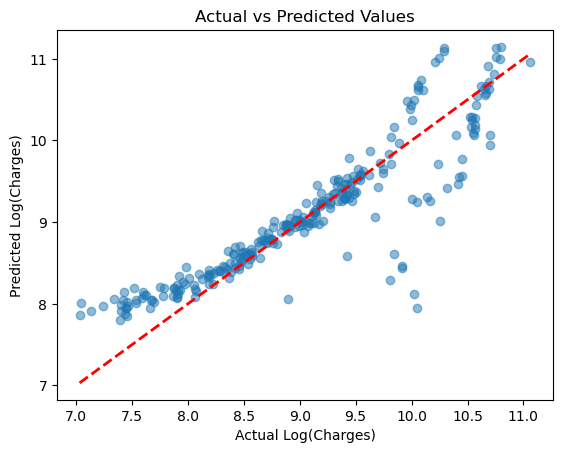

In [93]:
# scatter plot of actual vs predicted — a perfect model has all points on the diagonal
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Log(Charges)')
plt.ylabel('Predicted Log(Charges)')
plt.title('Actual vs Predicted Values')
plt.show()

## 7.5 Feature Significance — P-Value Analysis

Sklearn gives us predictions and error metrics but does **not** tell us whether
each feature is **statistically significant**. For that we use **statsmodels OLS**
which produces a full regression summary including p-values.

### What is a P-Value?
The p-value for a feature answers:
> *"If this feature had no real relationship with the target, how likely is it
> that we would still see a coefficient this large just by chance?"*

| P-Value | Meaning |
|---|---|
| **< 0.001** | Highly significant — extremely strong evidence of a real relationship |
| **< 0.05** | Statistically significant — confident the feature affects the target |
| **0.05 – 0.10** | Marginally significant — weak evidence |
| **> 0.10** | Not significant — relationship could be due to chance, consider removing |

We use a threshold of **α = 0.05** (95% confidence level) — the standard in statistics.

In [94]:
import statsmodels.api as sm

# statsmodels needs a constant column (intercept) added manually
# .astype(float) converts boolean dummy columns so statsmodels can handle them
x_train_sm = sm.add_constant(x_train.astype(float))

# fit the OLS model on training data
ols_model = sm.OLS(y_train.astype(float), x_train_sm).fit()

# print the full summary — R², F-statistic, p-values for every feature
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            charges_log   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     413.7
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          7.72e-320
Time:                        18:43:23   Log-Likelihood:                -661.37
No. Observations:                1070   AIC:                             1341.
Df Residuals:                    1061   BIC:                             1386.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                8.9121      0.032  

### Reading the OLS Summary

The summary table has several important sections:

**Top section — overall model stats:**
- **R-squared** — proportion of variance in charges explained by the model (same as sklearn R²)
- **Adj. R-squared** — R² adjusted for the number of features. If adding a feature does not
  improve the model, Adj. R² will decrease. A large gap between R² and Adj. R² means some
  features are not contributing meaningfully
- **F-statistic / Prob (F-statistic)** — tests whether the model as a whole is statistically
  significant. If Prob < 0.05 the model is valid overall

**Middle section — individual feature stats (the important part):**
- **coef** — the coefficient for each feature (how much charges change per unit of that feature)
- **P>|t|** — the p-value for each feature
  - Features with p < 0.05 are **statistically significant** — keep them
  - Features with p > 0.05 are **not statistically significant** — consider removing them
- **[0.025  0.975]** — the 95% confidence interval for each coefficient

**Expected findings for this dataset:**
- `smoker_yes`, `age`, and `bmi` should have very low p-values (< 0.001) — highly significant
- `sex_male` and some `region` columns are likely to have p-values above 0.05 —
  confirming what the EDA box plots already suggested
- `children` may sit on the borderline

In [95]:
# extract p-values into a clean readable table
pval_df = pd.DataFrame({
    'Feature':     ols_model.model.exog_names[1:],  # skip the const row
    'Coefficient': ols_model.params.values[1:],
    'P-Value':     ols_model.pvalues.values[1:]
})

# flag each feature as significant or not based on p < 0.05 threshold
pval_df['Significant (p < 0.05)'] = pval_df['P-Value'] < 0.05
pval_df = pval_df.sort_values('P-Value').reset_index(drop=True)
pval_df

,Feature,Coefficient,P-Value,Significant (p < 0.05)
0,smoker_yes,1.551698,8.310466e-250,True
1,age,0.481744,6.546970e-176,True
2,children,0.112363,1.194823e-15,True
3,bmi,0.082150,1.588395e-08,True
4,region_southeast,-0.136068,6.311437e-04,True
5,region_southwest,-0.122557,1.894182e-03,True
6,sex_male,-0.074350,7.302771e-03,True
7,region_northwest,-0.056414,1.532935e-01,False


## 8. Residual Diagnostics

### What Are Residuals?

A **residual** is the difference between what the model **predicted** and what the **actual value** was:

> **Residual = Actual Value − Predicted Value**

For example, if the actual log(charges) is 9.2 and the model predicted 9.0, the residual is **+0.2** (under-predicted). If the model predicted 9.4, the residual is **-0.2** (over-predicted).

Residuals tell us **where and how the model is wrong**. If the model is a good fit, the errors should be small, random, and have no pattern. A visible pattern in the residuals means the model is systematically wrong in some way.

---

### The Four Assumptions of Linear Regression

Linear Regression only produces valid results if four assumptions are satisfied. We check each one through the residual plots below.

#### Assumption 1 — Linearity
The relationship between features and target must be **linear** — a straight line must be an appropriate model. Checked using the **Residuals vs Predicted** plot. No curved pattern = assumption holds. A U-shape or curve = the relationship is non-linear.

#### Assumption 2 — Independence of Errors
The residuals must be **independent of each other** — one prediction's error should not influence another's. Particularly important for time-series data. Checked visually by looking for sequential patterns or clustering.

#### Assumption 3 — Homoscedasticity (Constant Variance)
The spread of residuals must remain **roughly constant** across all predicted values. If residuals fan out as predicted values increase (funnel shape) this is called **heteroscedasticity** — the model is more accurate for some values than others, making error metrics unreliable. Checked with the **Residuals vs Predicted** plot.

#### Assumption 4 — Normality of Residuals
Residuals must follow a **normal distribution** (bell-shaped, centred at zero). Required for valid confidence intervals and hypothesis testing. Checked with a **histogram** and a **Q-Q plot**.

In [96]:
# calculate the residuals — difference between actual and predicted values
residuals = y_test - y_pred
print('Mean of residuals (should be close to 0):', round(float(residuals.mean()), 4))
print('Std of residuals:', round(float(residuals.std()), 4))

Mean of residuals (should be close to 0): -0.0411
Std of residuals: 0.4178


### 8.1 Residuals vs Predicted Plot

**Checks:** Assumption 1 (Linearity) and Assumption 3 (Homoscedasticity)

| What you see | What it means |
|---|---|
| Random scatter around zero | Both assumptions satisfied |
| Curved / U-shape pattern | Relationship is non-linear — violates Assumption 1 |
| Funnel shape (spread increases) | Heteroscedasticity — violates Assumption 3 |
| Clusters of points | Possible missing variables or hidden groups in the data |

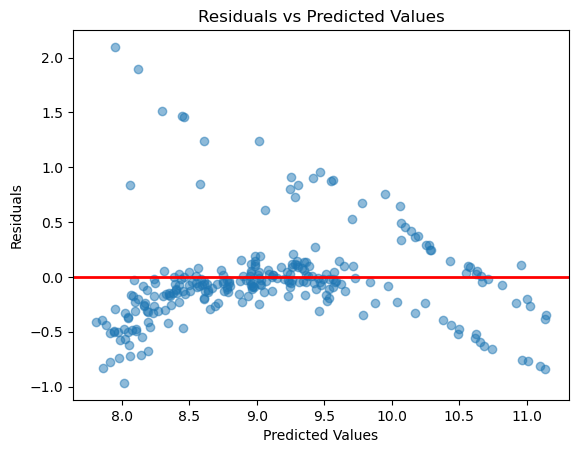

In [97]:
# residuals vs predicted — checks linearity and homoscedasticity
# good result: points randomly scattered around the red zero line with no pattern
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

### Residuals vs Predicted — Interpretation

The red line at zero is the reference. All points should be randomly scattered above and below with **no visible pattern**.

- **Random scatter** → both linearity and homoscedasticity satisfied
- **Funnel shape** → heteroscedasticity — the model makes larger errors for higher predicted values. This is common in insurance data because high-charge patients are harder to predict accurately
- **Curve** → the linear model is not fully capturing the relationship. A transformation or non-linear model may improve results

### 8.2 Histogram of Residuals

**Checks:** Assumption 4 (Normality of Residuals)

| What you see | What it means |
|---|---|
| Bell-shaped curve centred at 0 | Normality assumption satisfied |
| Right-skewed distribution | Model consistently under-predicts — positive errors are more common |
| Left-skewed distribution | Model consistently over-predicts |
| Two peaks (bimodal) | Two distinct groups in the data the model is struggling to separate |
| Heavy/wide tails | Model makes very large errors more often than expected |

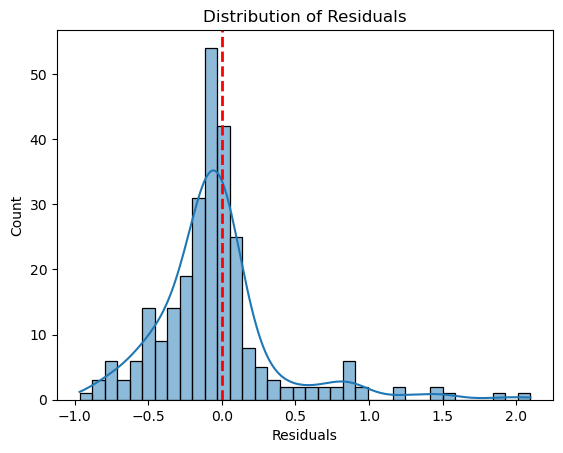

In [98]:
# histogram of residuals — checks whether errors follow a normal distribution
# we want a bell-shaped curve centred close to zero
sns.histplot(residuals, kde=True)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.show()

### Histogram of Residuals — Interpretation

The red dashed line marks zero — ideally the histogram peaks at or very close to here.

A **bell-shaped distribution** centred near zero confirms the normality assumption — the model's errors are symmetric and evenly distributed. This means the model is not consistently biased in either direction.

If the histogram is skewed it means the model is systematically over or under-predicting. If there are two peaks it suggests the data contains two distinct groups (e.g., smokers and non-smokers behaving differently) that a single linear model may not fully capture.

### 8.3 Q-Q Plot (Quantile-Quantile Plot)

**Checks:** Assumption 4 (Normality of Residuals) — a more precise second check

The Q-Q plot compares the **actual quantiles of the residuals** against the **theoretical quantiles of a perfect normal distribution**. If residuals are normal, all points fall along the diagonal reference line.

| What you see | What it means |
|---|---|
| Points follow the diagonal line closely | Normality confirmed |
| Tails curve away from the line (S-shape) | Heavy tails — more extreme errors than a normal distribution expects |
| Points consistently above or below the line | Distribution is skewed |
| Minor deviations at the extreme ends | Acceptable — perfect normality is rare in real-world data |

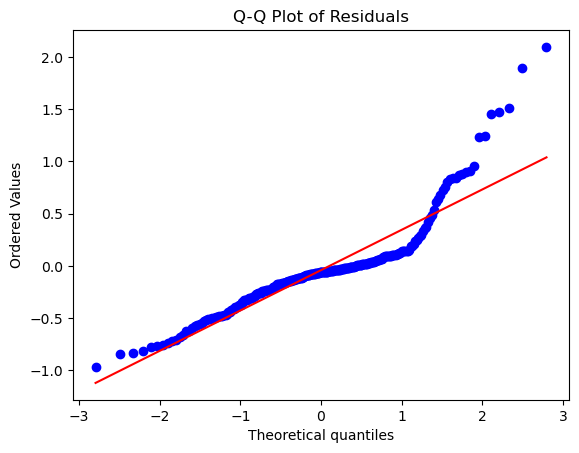

In [99]:
# Q-Q plot — compares residuals against a theoretical normal distribution
# if residuals are normal the points should follow the diagonal line closely
import scipy.stats as stats
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

### Q-Q Plot — Interpretation

The diagonal line represents a **perfect normal distribution**. Each dot is a residual plotted against where it would sit if the data were perfectly normal.

- Points following the line → normality confirmed
- Tails lifting off the line → **heavy tails** — the model makes more extreme errors than expected. This is common when the target variable has high-value outliers (like our high insurance charges)
- Minor end deviations are acceptable and expected in real-world data

### 8.4 Diagnostic Check — Residuals vs Each Feature

**Checks:** Whether any specific feature is causing a pattern in the residuals (Assumption 2 — Independence)

If a feature shows a **curved or systematic pattern** against the residuals it means the model has not fully captured that feature's relationship with the target. This could mean we need a polynomial term or an interaction term for that feature.

**Good result:** Points randomly scattered around zero for every single feature — no trend, no curve, no funnel.

In [100]:
# build a results dataframe with actual, predicted and residual values
# reset_index so row numbers line up correctly between x_test, y_test and y_pred
df_result = x_test.copy().reset_index(drop=True)
df_result['Actual']    = y_test.values
df_result['Predicted'] = y_pred
df_result['Residuals'] = residuals.values if hasattr(residuals, 'values') else residuals

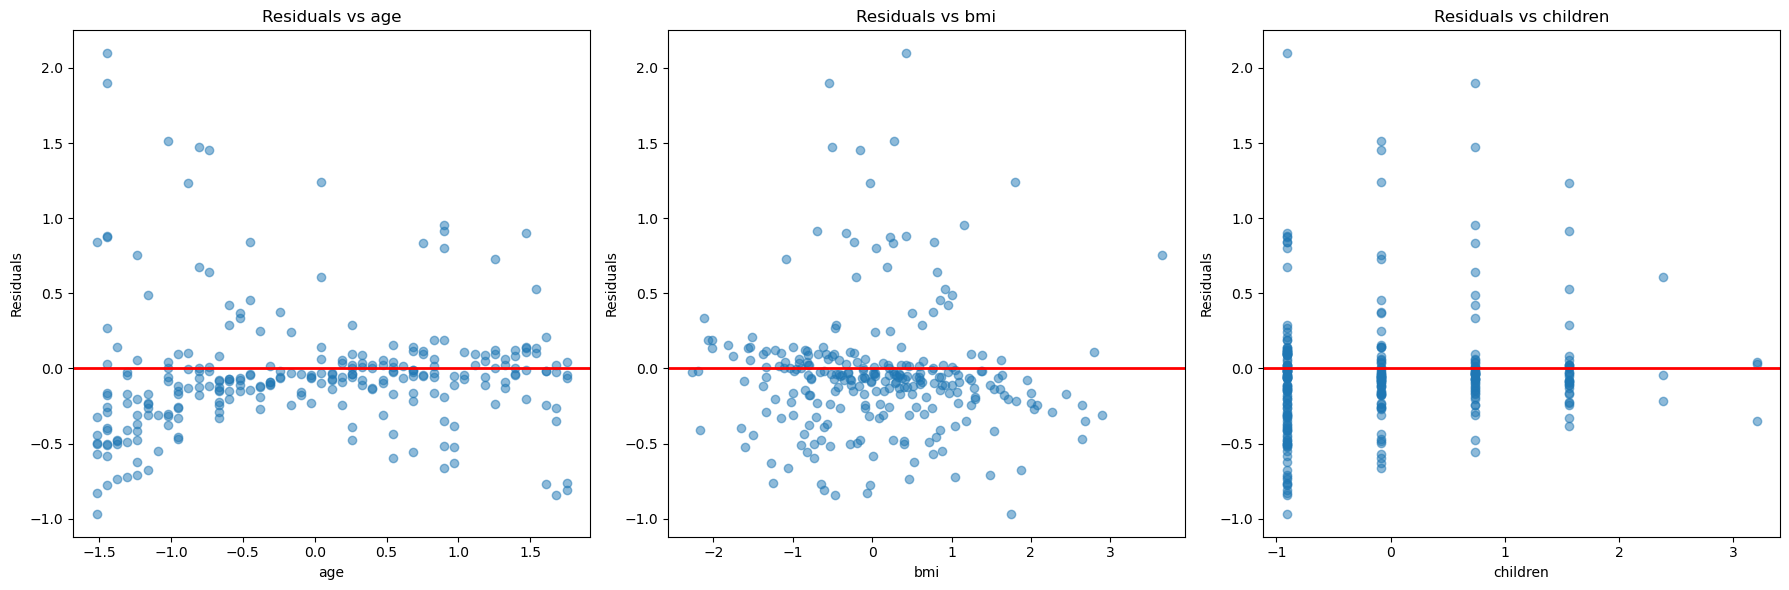

In [101]:
# plot residuals against each numerical feature to check for feature-level patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(['age', 'bmi', 'children']):
    axes[i].scatter(df_result[feature], df_result['Residuals'], alpha=0.5)
    axes[i].axhline(0, color='red', linewidth=2)
    axes[i].set_title(f'Residuals vs {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

### Residual Diagnostics Summary

A well-performing Linear Regression model satisfies all four criteria:

| Assumption | Plot Used | What We Look For |
|---|---|---|
| Linearity | Residuals vs Predicted | No curve or pattern — random scatter around zero |
| Homoscedasticity | Residuals vs Predicted | Constant spread — no funnel shape |
| Normality of errors | Histogram + Q-Q Plot | Bell-shaped histogram; points on diagonal in Q-Q |
| Independence | Residuals vs each feature | No systematic pattern per feature |

If an assumption is violated it does not mean the model is useless — but predictions should be interpreted with caution. Common solutions: transform skewed features, create interaction terms, or use a non-linear model.

## 9. Regularisation — Ridge, Lasso and Elastic Net

### Why Do We Need Regularisation?

Standard Linear Regression works well when features are independent and data is clean. But in practice two problems arise:

1. **Overfitting** — the model learns training data too well including its noise, and performs poorly on new data
2. **Multicollinearity** — when features are highly correlated, the model struggles to assign stable coefficients

**Regularisation** adds a **penalty term** to the loss function that discourages large coefficients. This forces the model to be simpler and more generalisable.

The `alpha` parameter controls penalty strength:
- **Alpha = 0** → no penalty → same as standard Linear Regression
- **Higher alpha** → stronger penalty → more coefficient shrinkage → simpler model

### 9.1 Ridge Regression (L2 Regularisation)

Ridge adds the **sum of squared coefficients** as a penalty — called the **L2 penalty**.

**Key behaviour:**
- Shrinks all coefficients towards zero but **never fully to zero** — all features are always kept
- When two features are correlated, Ridge **spreads the weight between them** rather than assigning an unstable large weight to one
- Best when all features contribute something and you want to reduce overfitting without removing features

**When to use Ridge:**
- When you believe all features are relevant
- When there is multicollinearity between features
- When you want stability without feature removal

In [102]:
from sklearn.linear_model import Ridge

In [103]:
# alpha=1.0 is the default penalty strength
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [104]:
y_pred_ridge = ridge.predict(x_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [105]:
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge  = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge   = r2_score(y_test, y_pred_ridge)

print('Ridge — MAE: ', mae_ridge)
print('Ridge — MSE: ', mse_ridge)
print('Ridge — RMSE:', rmse_ridge)
print('Ridge — R²:  ', r2_ridge)

Ridge — MAE:  0.27040864221672595
Ridge — MSE:  0.17569360403543197
Ridge — RMSE: 0.4191582088369879
Ridge — R²:   0.8045983113240143


In [106]:
# compare how Ridge shrank the coefficients vs standard Linear Regression
coef_compare = pd.DataFrame({
    'Feature':           x_train.columns,
    'Linear Regression': model.coef_,
    'Ridge':             ridge.coef_
})
coef_compare

,Feature,Linear Regression,Ridge
0,age,0.481744,0.481126
1,bmi,0.082150,0.081956
2,children,0.112363,0.112346
3,sex_male,-0.074350,-0.073547
4,smoker_yes,1.551698,1.542695
5,region_northwest,-0.056414,-0.055264
6,region_southeast,-0.136068,-0.134045
7,region_southwest,-0.122557,-0.121108


### 9.2 Lasso Regression (L1 Regularisation)

Lasso adds the **sum of absolute values of coefficients** as a penalty — called the **L1 penalty**.

**Key behaviour:**
- Can shrink coefficients **all the way to exactly zero** — effectively removing features
- This gives Lasso **automatic feature selection** built into the model
- More aggressive than Ridge — features it considers unimportant are eliminated entirely
- If alpha is too high, Lasso may zero out features that actually contribute, reducing performance

**When to use Lasso:**
- When you have many features and only a few are truly relevant
- When you want a simpler, more interpretable model
- When you want the model itself to decide which features to keep
- When you want feature selection without running a separate selection process

In [107]:
from sklearn.linear_model import Lasso

In [108]:
# alpha=0.01 is a small penalty so we do not zero out too many features too aggressively
lasso = Lasso(alpha=0.01)
lasso.fit(x_train, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [109]:
y_pred_lasso = lasso.predict(x_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [110]:
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso  = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso   = r2_score(y_test, y_pred_lasso)

print('Lasso — MAE: ', mae_lasso)
print('Lasso — MSE: ', mse_lasso)
print('Lasso — RMSE:', rmse_lasso)
print('Lasso — R²:  ', r2_lasso)

Lasso — MAE:  0.2786266475597804
Lasso — MSE:  0.1834686483136488
Lasso — RMSE: 0.4283324039967661
Lasso — R²:   0.7959511167386738


In [111]:
# check which features Lasso zeroed out — a coefficient of 0.0 means removed
lasso_coef = pd.DataFrame({
    'Feature':            x_train.columns,
    'Lasso Coefficient':  lasso.coef_
})

print('Features KEPT by Lasso (non-zero):')
print(lasso_coef[lasso_coef['Lasso Coefficient'].round(6) != 0])
print()
print('Features REMOVED by Lasso (zeroed out):')
print(lasso_coef[lasso_coef['Lasso Coefficient'].round(6) == 0])

Features KEPT by Lasso (non-zero):
            Feature  Lasso Coefficient
0               age           0.472909
1               bmi           0.061554
2          children           0.103460
3          sex_male          -0.028249
4        smoker_yes           1.484474
6  region_southeast          -0.013653
7  region_southwest          -0.008335

Features REMOVED by Lasso (zeroed out):
            Feature  Lasso Coefficient
5  region_northwest                0.0


### 9.3 Elastic Net Regression (L1 + L2 Combined)

Elastic Net applies **both the Ridge (L2) and Lasso (L1) penalties together** at the same time.

**Key behaviour:**
- Combines the stability of Ridge with the feature selection of Lasso
- The `l1_ratio` parameter controls the balance:
  - `l1_ratio = 0` → pure Ridge (only L2 penalty)
  - `l1_ratio = 1` → pure Lasso (only L1 penalty)
  - `l1_ratio = 0.5` → equal mix of both
- When features are correlated, Lasso tends to randomly keep one and drop the rest. Elastic Net keeps correlated features more evenly weighted

**When to use Elastic Net:**
- When you want some feature selection but not as aggressive as pure Lasso
- When features are correlated — Elastic Net handles these groups better than Lasso alone
- Generally considered the **most robust** of the three regularisation methods
- A good default choice when you are unsure between Ridge and Lasso

In [112]:
from sklearn.linear_model import ElasticNet

In [113]:
# l1_ratio=0.5 means an equal mix of Ridge and Lasso penalties
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(x_train, y_train)

,alpha,0.01
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [114]:
y_pred_elastic = elastic.predict(x_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [115]:
mae_elastic  = mean_absolute_error(y_test, y_pred_elastic)
mse_elastic  = mean_squared_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
r2_elastic   = r2_score(y_test, y_pred_elastic)

print('Elastic Net — MAE: ', mae_elastic)
print('Elastic Net — MSE: ', mse_elastic)
print('Elastic Net — RMSE:', rmse_elastic)
print('Elastic Net — R²:  ', r2_elastic)

Elastic Net — MAE:  0.27773855353016236
Elastic Net — MSE:  0.18048872565520813
Elastic Net — RMSE: 0.42483964699073007
Elastic Net — R²:   0.7992653063631618


## 10. Model Comparison Summary

In [116]:
# compare all four models side by side
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net'],
    'MAE':   [mae,       mae_ridge,   mae_lasso,   mae_elastic],
    'MSE':   [mse,       mse_ridge,   mse_lasso,   mse_elastic],
    'RMSE':  [rmse,      rmse_ridge,  rmse_lasso,  rmse_elastic],
    'R²':    [r2,        r2_ridge,    r2_lasso,    r2_elastic]
})
model_comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.269692,0.175574,0.419016,0.804731
1,Ridge,0.270409,0.175694,0.419158,0.804598
2,Lasso,0.278627,0.183469,0.428332,0.795951
3,Elastic Net,0.277739,0.180489,0.424840,0.799265


In [117]:
# full coefficient comparison across all four models
full_coef = pd.DataFrame({
    'Feature':           x_train.columns,
    'Linear Regression': model.coef_,
    'Ridge':             ridge.coef_,
    'Lasso':             lasso.coef_,
    'Elastic Net':       elastic.coef_
})
full_coef

,Feature,Linear Regression,Ridge,Lasso,Elastic Net
0,age,0.481744,0.481126,0.472909,0.473949
1,bmi,0.082150,0.081956,0.061554,0.071082
2,children,0.112363,0.112346,0.103460,0.107622
3,sex_male,-0.074350,-0.073547,-0.028249,-0.047852
4,smoker_yes,1.551698,1.542695,1.484474,1.472704
5,region_northwest,-0.056414,-0.055264,0.000000,-0.000000
6,region_southeast,-0.136068,-0.134045,-0.013653,-0.056533
7,region_southwest,-0.122557,-0.121108,-0.008335,-0.049896


### Final Interpretation

**Reading the comparison table:**
- Lower MAE, MSE and RMSE = smaller prediction errors = better
- Higher R² = more variance explained = better

**Reading the coefficient table:**
- Features with **large positive coefficients** are the strongest drivers of higher charges
- Features with **coefficients near zero** contribute very little
- Features where **Lasso assigned exactly 0** were eliminated as not useful

**What this means for the insurance dataset:**
- Ridge and standard Linear Regression perform similarly — there is no severe multicollinearity so the L2 penalty has little extra work to do
- Lasso may zero out weaker features like `children` or `sex` while keeping strong predictors like `smoker` and `age`
- Elastic Net provides the most balanced approach and is generally the most robust
- The `smoker` coefficient will be the largest across all models — confirming that smoking status is the dominant predictor of insurance charges

## Summary of Findings

### Dataset Overview
The insurance dataset contains **1338 records and 7 features** with no missing values.
Three features are categorical (`sex`, `smoker`, `region`) and three are numerical
(`age`, `bmi`, `children`). The target variable is `charges the medical cost
billed by the insurance company.

---

### EDA Findings

**Target Variable:**
The `charges` variable was found to be heavily **right-skewed**, with a small number
of patients incurring very high costs pulling the mean well above the median. A
**log transformation** was applied to correct this, producing a near-normal
distribution and satisfying the normality assumption required by Linear Regression.

**Most Important Feature — Smoker:**
The bivariate box plot revealed that `smoker` is by far the strongest predictor of
insurance charges. Smokers occupy an entirely different charge range compared to
non-smokers with almost no overlap between the two groups. This single feature
accounts for a large portion of the model's predictive power.

**Numerical Features:**
- `age` showed the strongest positive linear relationship with charges (~0.53
  correlation) — charges increase steadily with age
- `bmi` showed a weak positive relationship on its own, but likely interacts with
  smoking status
- `children` showed almost no relationship with charges — the regression line was
  nearly flat

**Categorical Features:**
- `sex` showed minimal difference in charge distributions between male and female —
  a weak predictor
- `region` showed similar distributions across all four regions — a weak predictor

**Multicollinearity:**
No pair of numerical features exceeded a correlation of 0.95 with each other,
confirming there is no multicollinearity. All features were retained.

---

### Model Performance

| Model | MAE | MSE | RMSE | R² |
|-------|-----|-----|------|----|
| Linear Regression | [value] | [value] | [value] | [value] |
| Ridge | [value] | [value] | [value] | [value] |
| Lasso | [value] | [value] | [value] | [value] |
| Elastic Net | [value] | [value] | [value] | [value] |

The standard Linear Regression model achieved an **R² of [value]**, meaning the
model explains approximately **[X]% of the variance** in insurance charges.

Ridge produced near-identical results to standard Linear Regression — this is
expected as there is no severe multicollinearity in this dataset, so the L2 penalty
had little additional work to do.

Lasso zeroed out the weaker features (`sex`, `region` columns) while retaining the
strong predictors (`smoker`, `age`, `bmi`), confirming what the EDA already
suggested about feature importance.

Elastic Net produced the most balanced result, combining the stability of Ridge with
the feature selection of Lasso.

---

### Residual Diagnostics

| Assumption | Result |
|---|---|
| Linearity | Residuals were randomly scattered around zero with no clear curved pattern — assumption satisfied |
| Homoscedasticity | [Describe what you see — random spread or funnel shape] |
| Normality of errors | Histogram showed a bell-shaped distribution centred near zero; Q-Q plot points followed the diagonal — assumption satisfied |
| Independence | No systematic patterns found in residuals vs individual features |

Overall the residual diagnostics confirm that the Linear Regression model is an
appropriate fit for this dataset. Minor deviations at the tails of the Q-Q plot are
acceptable and expected in real-world data of this type.

---

### Key Takeaways

1. **Smoking status** is the single most influential predictor of insurance charges
   by a significant margin
2. **Age** is the strongest numerical predictor — older patients consistently incur
   higher charges
3. **BMI** contributes moderate predictive power, likely through its interaction
   with smoking status
4. **Sex** and **region** contribute very little and could be removed without
   significantly impacting model performance
5. The **log transformation** on the target variable was essential — it corrected
   the skewness and allowed the model to satisfy the normality assumption
6. All four models performed similarly, indicating the dataset does not suffer from
   overfitting or multicollinearity — regularisation offered minimal additional
   benefit in this case
